<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/neuralNetworkForClassification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###This notebook is to study about the classification models of Deep Learning with Neural Networks
------
**Classification is an algorithm which classifies which class a particular sample belongs to.** (eg: if an email belongs to Spam class or Not Spam Class)  
Types of Classification:-   
•Binary Classification  
•Multiclass Classification  
•Multilabel Classification

###Basic Architecture of Classification Model
----
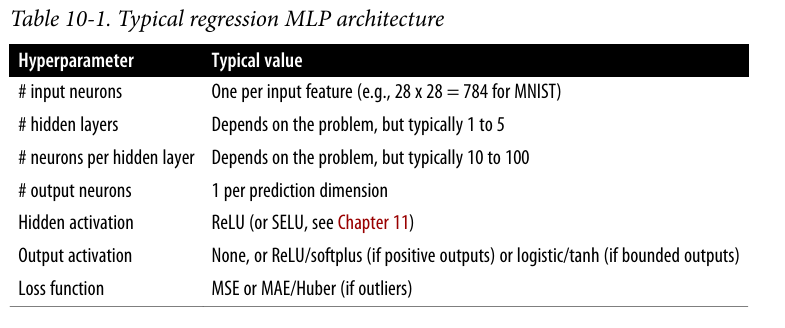


#Creating Dataset to view and fit

In [1]:
from sklearn.datasets import make_circles
# Making 1000 samples
n_samples = 1000

# Creating Circles
x,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

In [2]:
# Checking out features and labels
x,y[:10]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

Our data is little hard to understand, let's visualize it

In [3]:
import pandas as pd
circles = pd.DataFrame({"X0":x[:,0],"X1":x[:,1],"labels":y})
circles

,X0,X1,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


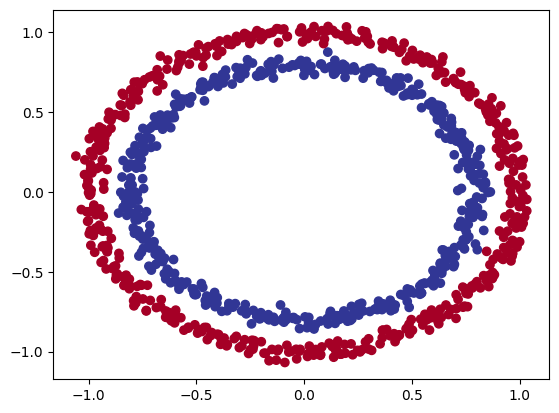

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y, cmap=plt.cm.RdYlBu)

In [5]:
# checking shapes of our features and labels
x.shape,y.shape,len(x),len(y)

((1000, 2), (1000,), 1000, 1000)

## Steps in Modelling
----
1.Create or import a model  
2.Compile the model  
3.Fit the model  
4.Evaluate the model  
5.Tweak  
6.Evaluate

In [6]:
import tensorflow as tf

In [7]:
#Setting seed
tf.random.set_seed(42)
# Model Building
model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# Compiling Model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer = tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
#Fitting with data
model_1.fit(x,y,epochs=5)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4867 - loss: 4.8649
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4745 - loss: 4.4505
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5105 - loss: 0.8277
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5187 - loss: 0.7129
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5154 - loss: 0.6968


In [8]:
# Let's try to improve our model
model_1.fit(x,y,epochs=5,verbose=0)
model_1.evaluate(x,y) # it is not right to evaluate on same traininig data

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4955 - loss: 0.6929


[0.6932308673858643, 0.5]

Since we're working on a binary classification problem and our model is getting around 50% accuracy. It's basically guessing and not actually learning

In [9]:
# Let's try adding an extra layer
tf.random.set_seed(42)
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
])
model2.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
model2.fit(x,y,epochs=200,verbose=0)
model2.evaluate(x,y) # not much happened, results are similar

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4690 - loss: 0.6935


[0.6933857798576355, 0.46299999952316284]

## Improving the model  
We can do perform follwing updates to check if our model improves   
1. Create a model - we might add layers or increase the number of hidden units within a layer  
2. Compiling a model - here we might choose a different optimization function such as ADAM instead of SGD    
3. Fitting a model- perhaps we might fit our model for more epochs for longer learning period


In [10]:
# This time let's try to add one exrtra layer with more neurons.
tf.random.set_seed(42)
model3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
model3.fit(x,y,epochs=200,verbose=0)


In [11]:
model3.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4949 - loss: 0.6920


[0.6938527226448059, 0.47699999809265137]

At this point we can notice that the model is not improving at all. The adjustment of the above hyperparameters seemed to work in case of regression model training

To Visualize our model's prediction , let's create a function **"plot_decision-boundary"**,this function will:   

*Take in a trained model, feature (x) and labels (y)  
*Create a meshgrid of the different x values   
*Make predictions across the meshgrid  
*Plot the predictions as well as a line between zones (where each unique class falls)  
**NOTE:** Study about Meshgrid    
link-https://www.geeksforgeeks.org/python/numpy-meshgrid-function/

In [12]:
import numpy as np

Resource: https://cs231n.github.io/

In [13]:
def plot_decision_boundary(model,x,y):
  """Plot the decision boundary created by a model predicting on X"""
  #Define the axis boundaries of the plot and create a meshgrid
  x_min,x_max = x[:,0].min()-0.1,x[:,0].max()+0.1
  y_min,y_max=x[:,1].min()-0.1,x[:,1].max()+0.1
  xx,yy=np.meshgrid(np.linspace(x_min,x_max,100),
                    np.linspace(y_min,y_max,100))

  #Create x value (we're going to make predictions on these)
  x_in = np.c_[(xx.ravel(),yy.ravel())] # stack 2D arrays together

  #Make predictions
  y_pred = model.predict(x_in)

  #Check for multi-class
  if len(y_pred[0])>1:
    print("doing multiclass classification")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("Doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7)
  plt.scatter(x[:,0],x[:,1],c=y,s=40,cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


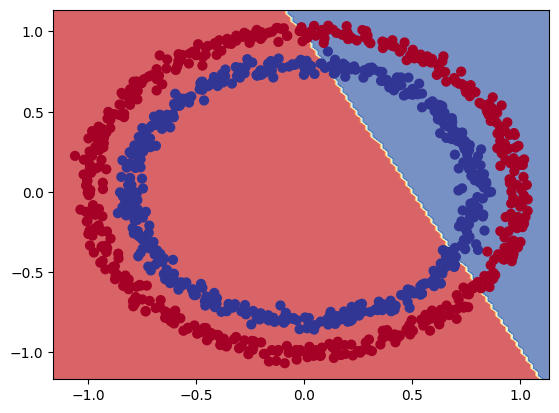

In [14]:
# Let's try decision boundary
plot_decision_boundary(model3,x,y)

Explanation  : So our model3 is trained and put to set with our classification dataset. The model3 is a linear model which draws a line to predict the outputs. However, in our current dataset, we have two circles, one inside another, and our model is trying to plot a line with least loss. However, a straight line model cannot classify and perform well on our current dataset.

In [15]:
# Let's try the model for regression model
x_reg = tf.range(0,1000,5)
x_reg = tf.expand_dims(x_reg, axis=-1)
y_reg = tf.range(100,1100,5)


#Splitting
x_reg_train= x_reg[:150]
x_reg_test = x_reg[150:]
y_reg_train= y_reg[:150]
y_reg_test = y_reg[150:]


In [16]:
x_reg_train.shape,y_reg_train.shape

(TensorShape([150, 1]), TensorShape([150]))

In [17]:
tf.random.set_seed(42)
model3= tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss= tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
model3.fit(x_reg_train,y_reg_train,epochs=100)
model3.evaluate(x_reg_test,y_reg_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 503.8997 - mae: 503.8997
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 415.7806 - mae: 415.7806 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 325.6108 - mae: 325.6108 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 231.8779 - mae: 231.8779 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 132.8941 - mae: 132.8941 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 46.8674 - mae: 46.8674 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 76.2910 - mae: 76.2910 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 77.6241 - mae: 77.6241 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 51.6306 - mae: 51.6306 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 44.6229 - mae: 44.6229 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.4696 - mae: 45.4696 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 41.5005 - mae: 41.5005 
Epoch 13/100
5

[62.23005676269531, 62.23005676269531]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


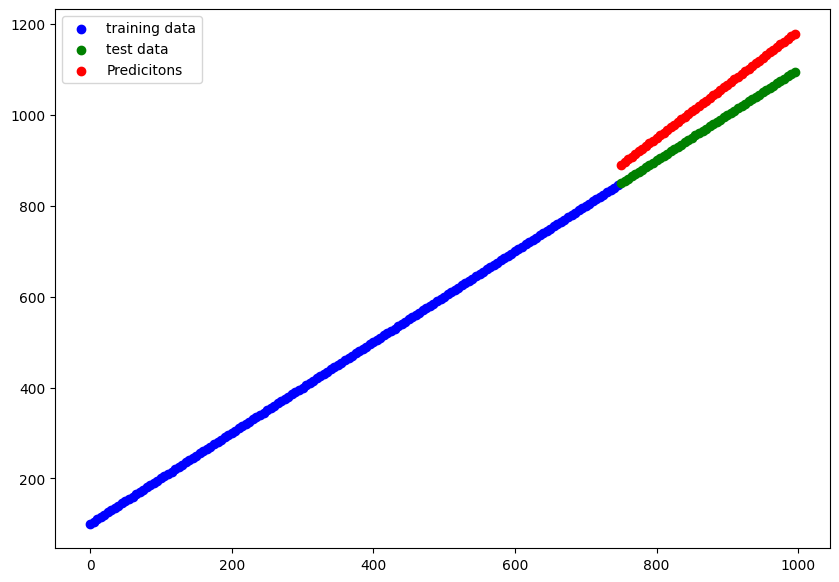

In [18]:
y_reg_pred=model3.predict(x_reg_test) # PRedictions

#Plotting model's predictions
plt.figure(figsize=(10,7))
plt.scatter(x_reg_train,y_reg_train, c='b', label="training data")
plt.scatter(x_reg_test,y_reg_test,c='g',label="test data")
plt.scatter(x_reg_test,y_reg_pred,c='r',label="Predicitons")
plt.legend();

#ReLU (Rectified Linear Unit) is defined as:

𝑓(𝑥)=max(0,𝑥)  
f(x)=max(0,x)

That means:

if
𝑥
<
0
x<0 → output = 0

if
𝑥
≥
0
x≥0 → output = x

##Adding Non-linearity to a linearly inseparable dataset.  
Non-linear activations- Relu, Sigmoid, Tan

In [19]:
x.shape,y.shape

((1000, 2), (1000,))

In [20]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1),
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4830 - loss: 4.6734
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4830 - loss: 3.5802
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.7689
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.0048
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 1.1661
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 1.1015
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 1.0654
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 1.0342
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 1.0067
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 0.9822
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 0.9602
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [21]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6463 - loss: 0.6462


[0.651935875415802, 0.6209999918937683]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


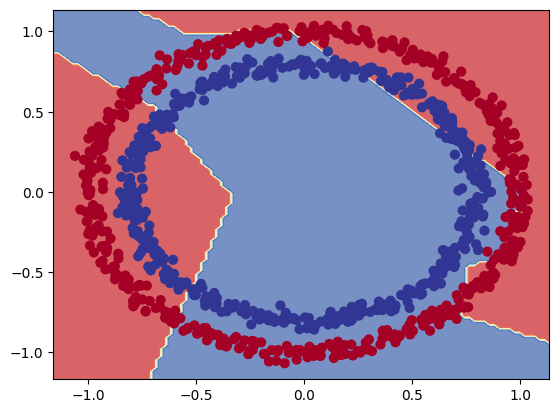

In [22]:
plot_decision_boundary(model4,x,y)

### Our model did not perform good above but we have not yet tried output layer activation.   
### Let's try sigmoid (for binary classification) as output layer activation. Softmax( for multi class classification)

In [23]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation ="sigmoid")
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4991 - loss: 0.6967
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5037 - loss: 0.6948
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5023 - loss: 0.6939
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5002 - loss: 0.6933
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5065 - loss: 0.6929
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5059 - loss: 0.6925
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5087 - loss: 0.6921
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5088 - loss: 0.6917
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5126 - loss: 0.6914
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5132 - loss: 0.6911
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5132 - loss: 0.6908
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [24]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7328 - loss: 0.5564


[0.5611745119094849, 0.7239999771118164]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


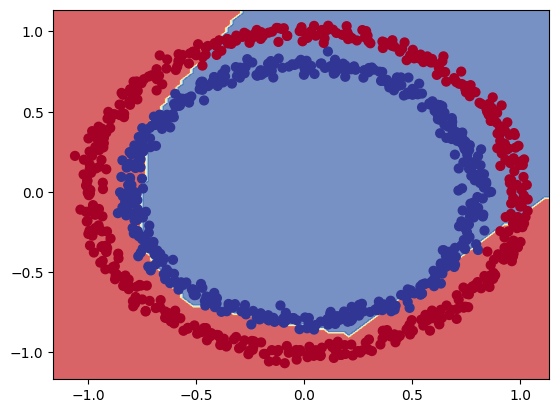

In [25]:
plot_decision_boundary(model4,x,y)

A sigmoid is an activation function which takes in inputs and return 0 or 1 as output, that is why is used for binary classification.   
Now we will convert a straight line to a non-linear using sigmoid

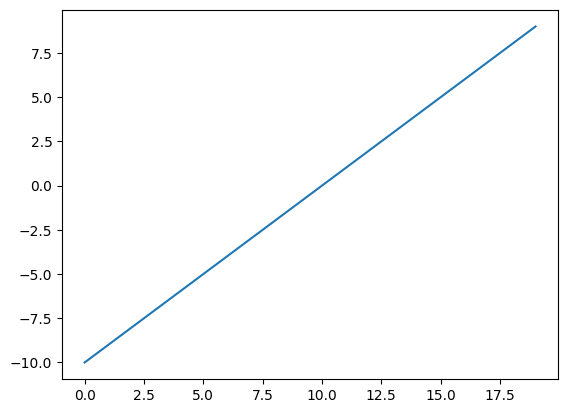

In [26]:
A = tf.cast(tf.range(-10,10), tf.float32)
plt.plot(A)

In [27]:
def sigmoid(x):
    return 1/(1+tf.exp(-x))
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397868e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726230e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105854e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

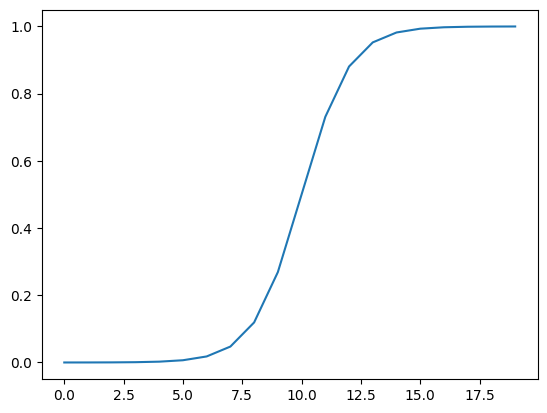

In [28]:
plt.plot(sigmoid(A))

In [29]:
# Creating relu function
def relu(x):
    return tf.maximum(0,x)
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

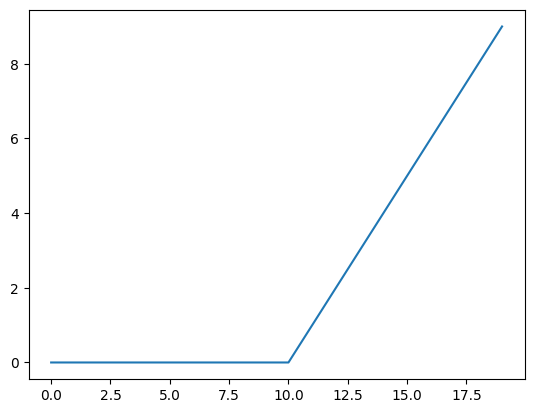

In [30]:
plt.plot(relu(A))